In [4]:
import yaml
import pypsa
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

idx = pd.IndexSlice

In [126]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_2500.nc'
)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_2500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [127]:
with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [134]:
from tqdm import tqdm

b_data = []
g_data = []

for wiggle in tqdm(range(0, 4250, 250)):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / f'base_s_50__3H-T-H-B-I-A-dist1_2030_free_{wiggle}.nc'
    )

    balance = n.statistics.energy_balance(aggregate_time=False, nice_names=True)
    balance = balance.loc[balance.index.get_level_values("bus_carrier").isin(["AC", "low voltage"])]

    balance = balance.loc[balance.index.get_level_values(1) != 'electricity distribution grid'].mul(1e-3)

    balance.index = balance.index.get_level_values(1)
    balance = balance.T
    balance.index = balance.index.strftime('%Y-%m-%d')

    balance = balance.groupby(balance.index).sum()

    batteries = balance[['battery discharger', 'home battery discharger']].sum(axis=1).rename(wiggle) * 3
    gaspower = balance[['Combined-Cycle Gas']].sum(axis=1).rename(wiggle) * 3

    b_data.append(batteries)
    g_data.append(gaspower)

100%|██████████| 17/17 [03:22<00:00, 11.92s/it]


In [135]:
b_data = pd.concat(b_data, axis=1)
g_data = pd.concat(g_data, axis=1)

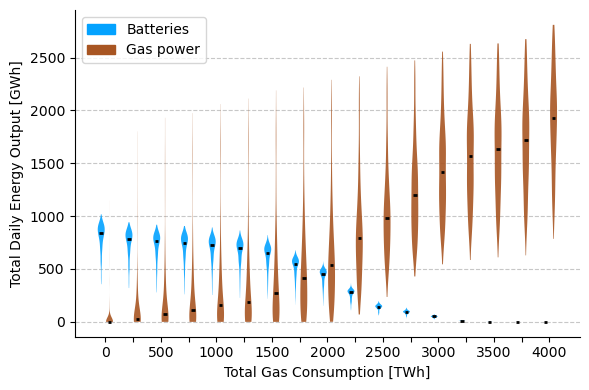

In [153]:
fig, ax = plt.subplots(figsize=(6, 4))

positions = []
data = []
labels = []
offset = 0.15  # Offset for side-by-side violins at same x

# Define tech names for colors
battery_techs = ['battery discharger', 'home battery discharger']
gaspower_tech = 'Combined-Cycle Gas'

# Get colors from tech_colors if available, else fallback
battery_color = tech_colors.get('shipping', 'tab:blue')
gaspower_color = tech_colors.get(gaspower_tech, 'tab:orange')

for i, col in enumerate(b_data.columns):
    x_pos = i
    # Prepare battery data and gaspower data for this column (wiggle step)
    b_vals = b_data[col].dropna().values
    g_vals = g_data[col].dropna().values

    # Add violin for batteries
    parts1 = ax.violinplot(b_vals, positions=[x_pos - offset], widths=0.25, showmeans=False, showextrema=False, showmedians=True)
    for pc in parts1['bodies']:
        pc.set_facecolor(battery_color)
        pc.set_alpha(0.9)
    # Make the median line black for batteries
    if "cmedians" in parts1:
        # "cmedians" is a LineCollection, not iterable
        median = parts1["cmedians"]
        median.set_color("black")
        median.set_linewidth(2)

    # Add violin for gaspower
    parts2 = ax.violinplot(g_vals, positions=[x_pos + offset], widths=0.25, showmeans=False, showextrema=False, showmedians=True)
    for pc in parts2['bodies']:
        pc.set_facecolor(gaspower_color)
        pc.set_alpha(0.9)
    # Make the median line black for gaspower
    if "cmedians" in parts2:
        median = parts2["cmedians"]
        median.set_color("black")
        median.set_linewidth(2)

# Set x-ticks to the wiggle values but only show every second label
xtick_positions = list(range(len(b_data.columns)))
xtick_labels = [str(col) if i % 2 == 0 else "" for i, col in enumerate(b_data.columns)]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=0)
ax.set_xlabel("Total Gas Consumption [TWh]")
ax.set_ylabel("Total Daily Energy Output [GWh]")

# Add legend manually
import matplotlib.patches as mpatches
battery_patch = mpatches.Patch(color=battery_color, label='Batteries')
gaspower_patch = mpatches.Patch(color=gaspower_color, label='Gas power')
ax.legend(handles=[battery_patch, gaspower_patch])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(Path.cwd().parent.parent / 'gas_resilience' / 'imgs' / 'battery_gas_tradeoff.pdf', bbox_inches='tight')
plt.show()

In [ ]:
incs = balance_u.clip(lower=0).sum(axis=1) 
incs = incs.loc[incs > incs.sum() * 0.01]
outs = balance_u.clip(upper=0).abs().sum(axis=1)
outs = outs.loc[outs > outs.sum() * 0.01]

balance_u = balance_u.loc[incs.index.union(outs.index)]
balance_l = balance_l.loc[incs.index.union(outs.index)]

No color found for these techs in u_pos: ['heat100-200 industry industrial heat pump high temperature', 'heat<100 industry industrial heat pump medium temperature', 'rural ground heat pump']
No color found for these techs in l_pos: ['heat100-200 industry industrial heat pump high temperature', 'heat<100 industry industrial heat pump medium temperature', 'rural ground heat pump']


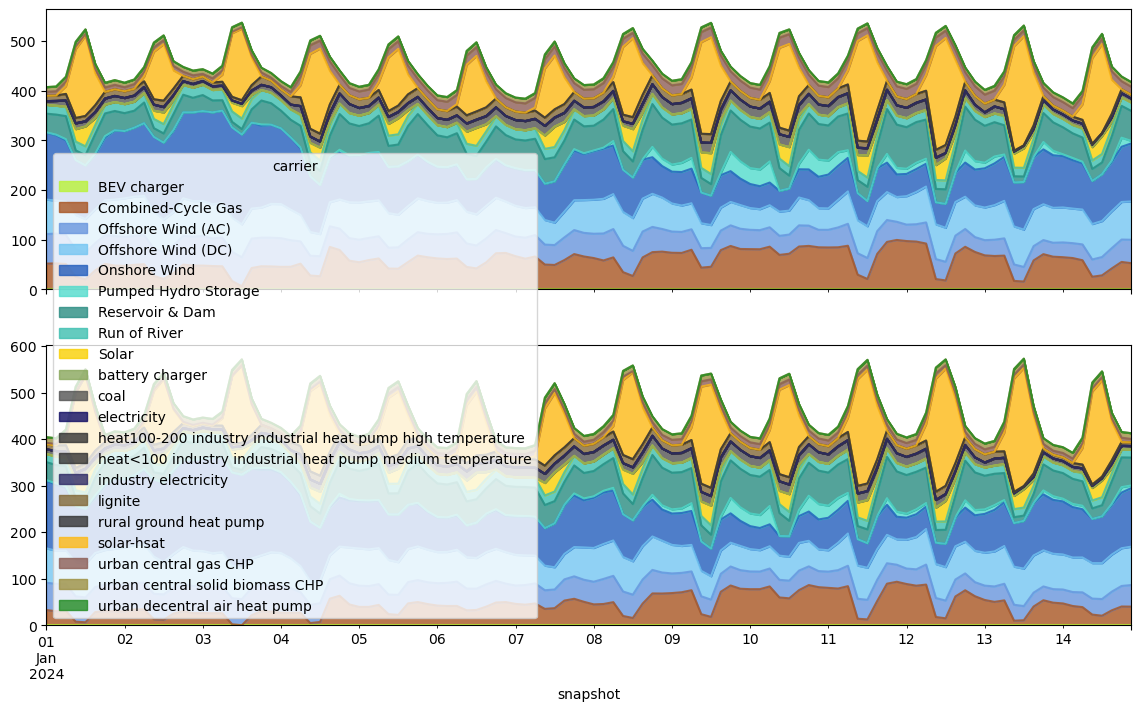

In [85]:
import numpy as np

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

u_pos = balance_u[balance_u > 0].replace(np.nan, 0).T
u_neg = balance_u[balance_u < 0].replace(np.nan, 0).T

l_pos = balance_l[balance_l > 0].replace(np.nan, 0).T
l_neg = balance_l[balance_l < 0].replace(np.nan, 0).T

# Prepare colors for u_pos and l_pos columns, and record missing techs
u_colors = []
u_missing_colors = []
for col in u_pos.columns:
    color = tech_colors.get(col, "#333333")
    u_colors.append(color)
    if color == "#333333" and col not in u_missing_colors:
        u_missing_colors.append(col)

l_colors = []
l_missing_colors = []
for col in l_pos.columns:
    color = tech_colors.get(col, "#333333")
    l_colors.append(color)
    if color == "#333333" and col not in l_missing_colors:
        l_missing_colors.append(col)

# Area plot for positive contributions, using tech_colors for columns
u_pos.plot.area(
    ax=axs[0],
    legend=False,
    color=u_colors,
    alpha=0.8
)
# u_neg.plot.area(ax=axs[0], legend=False, color=[tech_colors.get(col, "#333333") for col in u_neg.columns], alpha=0.5)

# Make it clear where zero is
axs[0].axhline(0, color='k', linewidth=1)
l_pos.plot.area(
    ax=axs[1],
    legend=True,
    color=l_colors,
    alpha=0.8
)

if u_missing_colors:
    print("No color found for these techs in u_pos:", u_missing_colors)
if l_missing_colors:
    print("No color found for these techs in l_pos:", l_missing_colors)

plt.show()

In [168]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_500.nc'
)
bal = n.statistics.energy_balance(aggregate_time=False)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


<Axes: xlabel='snapshot'>

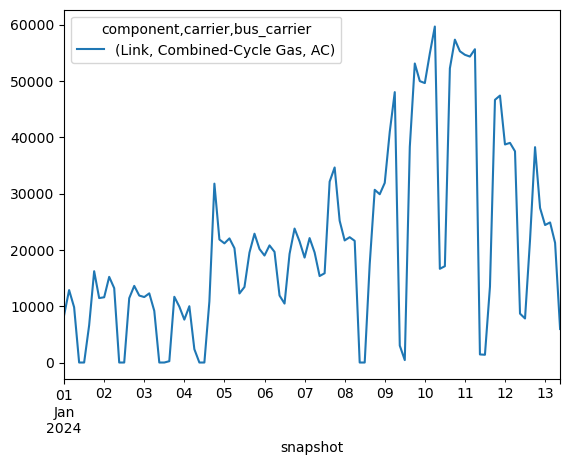

In [164]:
bal.loc[idx[:, 'Combined-Cycle Gas', 'AC'], :].T.iloc[:100].plot()

<Axes: xlabel='snapshot'>

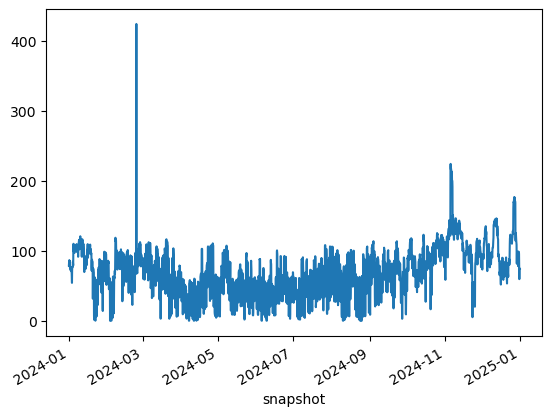

In [162]:
ac_buses = n.buses.loc[n.buses.carrier == 'AC']
n.buses_t.marginal_price.loc[:, ac_buses.index].mean(axis=1).plot()

In [167]:
bal.loc[idx[:, :, 'gas'], :].clip(upper=0).sum()

snapshot
2024-01-01 00:00:00   -100178.50661
2024-01-01 03:00:00   -128568.15907
2024-01-01 06:00:00   -128895.72670
2024-01-01 09:00:00   -103485.29261
2024-01-01 12:00:00   -103054.33700
                           ...     
2024-12-31 09:00:00   -132426.80494
2024-12-31 12:00:00   -124340.93932
2024-12-31 15:00:00   -136833.29487
2024-12-31 18:00:00   -164086.89141
2024-12-31 21:00:00   -112788.38578
Length: 2920, dtype: float64

In [169]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_4000.nc'
)
bal = n.statistics.energy_balance(aggregate_time=False)
bal.loc[idx[:, :, 'gas'], :].clip(upper=0).sum()

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_4000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


snapshot
2024-01-01 00:00:00   -532065.02911
2024-01-01 03:00:00   -637425.70463
2024-01-01 06:00:00   -659625.92624
2024-01-01 09:00:00   -599771.02589
2024-01-01 12:00:00   -567919.42434
                           ...     
2024-12-31 09:00:00   -603345.68824
2024-12-31 12:00:00   -562726.71724
2024-12-31 15:00:00   -684199.58701
2024-12-31 18:00:00   -693581.41797
2024-12-31 21:00:00   -567113.90109
Length: 2920, dtype: float64